# Statistical Modeling – Session 6

## Qualitative Prädiktoren, Interaktionen und Polynomterme

Dieses Notebook ist als parallele Code-Demo zur Sitzung gedacht.  
Es verwendet einen synthetischen Fertigungsdatensatz, damit alle Beispiele ohne externe Dateien laufen.

**Lernziele**

- qualitative Prädiktoren mit `C(...)` in ein Regressionsmodell aufnehmen
- Referenzkategorien verstehen und gezielt ändern
- Dummy-Kodierung sichtbar machen
- additive Modelle von Interaktionsmodellen unterscheiden
- Polynomterme mit `I(x**2)` verwenden
- Modelle mit `R^2`, angepasstem `R^2`, F-Tests und Residualplots vergleichen


## 1. Pakete importieren

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
import statsmodels.api as sm

pd.set_option("display.precision", 3)
np.random.seed(42)

## 2. Synthetischen Datensatz erzeugen

Wir erzeugen Daten aus einer kleinen Fertigungssituation.

**Zielgröße**

- `time`: Bearbeitungszeit in Sekunden

**Prädiktoren**

- `order_size`: Auftragsgröße
- `temperature`: Umgebungstemperatur
- `process`: Prozessvariante A, B oder C
- `shift`: Früh-, Spät- oder Nachtschicht

Die Daten enthalten absichtlich:
- einen nichtlinearen Zusammenhang mit `order_size`,
- Prozessunterschiede,
- eine Interaktion zwischen `order_size` und `process`,
- Schichteffekte.


In [2]:
n = 180

order_size = np.random.uniform(20, 100, size=n)
temperature = np.random.normal(22, 3.5, size=n)

process = np.random.choice(["A", "B", "C"], size=n, p=[0.45, 0.35, 0.20])
shift = np.random.choice(["Frueh", "Spaet", "Nacht"], size=n, p=[0.45, 0.35, 0.20])

# Wahre Struktur für die Simulation
process_effect = np.select(
    [process == "A", process == "B", process == "C"],
    [0, 6, -4]
)

shift_effect = np.select(
    [shift == "Frueh", shift == "Spaet", shift == "Nacht"],
    [0, 3, 8]
)

# Prozess B reagiert stärker auf Auftragsgröße, Prozess C etwas schwächer
slope_extra = np.select(
    [process == "A", process == "B", process == "C"],
    [0.00, 0.12, -0.08]
)

noise = np.random.normal(0, 5, size=n)

time = (
    35
    + 0.55 * order_size
    + 0.006 * (order_size - 65) ** 2
    + 0.70 * (temperature - 22)
    + process_effect
    + shift_effect
    + slope_extra * order_size
    + noise
)

df = pd.DataFrame({
    "time": time,
    "order_size": order_size,
    "temperature": temperature,
    "process": process,
    "shift": shift
})

df.head()

,time,order_size,temperature,process,shift
0,65.275,49.963,19.259,A,Spaet
1,78.757,96.057,20.873,C,Frueh
2,83.699,78.560,24.847,A,Frueh
3,71.044,67.893,17.692,A,Frueh
4,58.356,32.481,22.796,C,Frueh


## 3. Erste Übersicht

Bevor wir modellieren, prüfen wir kurz die Struktur der Daten.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         180 non-null    float64
 1   order_size   180 non-null    float64
 2   temperature  180 non-null    float64
 3   process      180 non-null    object 
 4   shift        180 non-null    object 
dtypes: float64(3), object(2)
memory usage: 7.2+ KB


In [4]:
df.describe(include="all")

,time,order_size,temperature,process,shift
count,180.000,180.000,180.000,180,180
unique,NaN,NaN,NaN,3,3
top,NaN,NaN,NaN,A,Frueh
freq,NaN,NaN,NaN,71,94
mean,74.919,57.769,22.263,NaN,NaN
std,16.733,23.524,3.465,NaN,NaN
min,45.562,20.442,10.656,NaN,NaN
25%,61.720,37.573,19.668,NaN,NaN
50%,72.250,57.131,22.572,NaN,NaN
75%,84.495,78.333,24.426,NaN,NaN


In [5]:
df["process"].value_counts()

process
A    71
B    61
C    48
Name: count, dtype: int64

In [6]:
df["shift"].value_counts()

shift
Frueh    94
Spaet    59
Nacht    27
Name: count, dtype: int64

## 4. Scatterplot: Auftragsgröße und Bearbeitungszeit

Zuerst betrachten wir den Zusammenhang zwischen `order_size` und `time` ohne Modell.

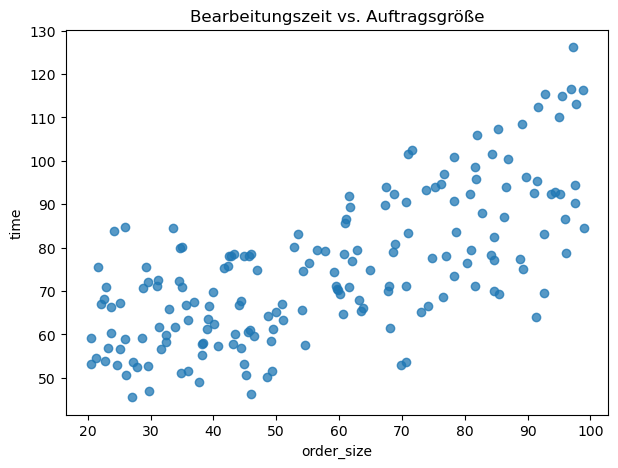

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["order_size"], df["time"], alpha=0.75)
ax.set_xlabel("order_size")
ax.set_ylabel("time")
ax.set_title("Bearbeitungszeit vs. Auftragsgröße")
plt.show()

## 5. Ein erstes lineares Modell

Wir beginnen absichtlich zu einfach:

$$
\text{time} = \beta_0 + \beta_1 \cdot \text{order\_size} + \varepsilon
$$


In [8]:
m1 = smf.ols("time ~ order_size", data=df).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     171.6
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           6.96e-28
Time:                        23:47:49   Log-Likelihood:                -701.29
No. Observations:                 180   AIC:                             1407.
Df Residuals:                     178   BIC:                             1413.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     46.1317      2.372     19.447      0.0

**Diskussionsfragen**

1. Was bedeutet der Koeffizient von `order_size`?
2. Ist dieses Modell plausibel, wenn der Scatterplot eine Krümmung zeigt?
3. Was sagt das Modell noch nicht über Prozessvarianten oder Schichten?


In [32]:
m1m = smf.ols("time ~ order_size + temperature", data=df).fit()
print(m1m.summary())

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.526
Method:                 Least Squares   F-statistic:                     100.4
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           7.13e-30
Time:                        23:57:01   Log-Likelihood:                -693.78
No. Observations:                 180   AIC:                             1394.
Df Residuals:                     177   BIC:                             1403.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      24.6852      5.921      4.169      

## 6. Qualitativer Prädiktor: Prozessvariante

Mit `C(process)` behandelt `statsmodels` die Variable als kategorial.

Standardmäßig wird eine Referenzkategorie gewählt. Die Koeffizienten der anderen Kategorien sind dann Differenzen zur Referenzkategorie.


In [9]:
m_process = smf.ols("time ~ order_size + C(process)", data=df).fit()
print(m_process.summary())

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     275.3
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.26e-66
Time:                        23:47:49   Log-Likelihood:                -605.50
No. Observations:                 180   AIC:                             1219.
Df Residuals:                     176   BIC:                             1232.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          45.0304      1.505     

### Referenzkategorie erkennen

Wenn im Output z. B. `C(process)[T.B]` und `C(process)[T.C]` erscheinen, dann ist die fehlende Kategorie die Referenzkategorie.

Hier also typischerweise: `process = A`.


In [10]:
df.groupby("process")["time"].mean()

process
A    71.568
B    88.321
C    62.844
Name: time, dtype: float64

## 7. Dummy-Kodierung sichtbar machen

Die Formelnotation macht die Dummy-Kodierung automatisch.  
Wir können sie aber mit `pd.get_dummies(...)` sichtbar machen.


In [11]:
pd.get_dummies(df[["process"]], drop_first=True).head(10)

,process_B,process_C
0,False,False
1,False,True
2,False,False
3,False,False
4,False,True
5,False,False
6,False,False
7,False,True
8,False,True
9,True,False


**Wichtig**

Bei drei Kategorien entstehen mit Intercept nur zwei Dummy-Variablen.  
Die ausgelassene Kategorie ist die Referenzkategorie.

Warum nicht drei Dummies plus Intercept?  
Weil dann gilt:

\[
D_A + D_B + D_C = 1
\]

Diese Spalte ist identisch mit der Intercept-Spalte.


## 8. Referenzkategorie explizit ändern

Manchmal möchte man eine andere Referenzkategorie wählen.  
Zum Beispiel `process = C` statt `process = A`.


In [12]:
m_ref_c = smf.ols(
    "time ~ order_size + C(process, Treatment(reference='C'))",
    data=df
).fit()

print(m_ref_c.summary())

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     275.3
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.26e-66
Time:                        23:47:49   Log-Likelihood:                -605.50
No. Observations:                 180   AIC:                             1219.
Df Residuals:                     176   BIC:                             1232.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

**Diskussionsfragen**

1. Welche Koeffizienten ändern sich durch die neue Referenzkategorie?
2. Bleiben die fitted values gleich?
3. Warum können sich einzelne p-Werte ändern, obwohl das Modell dieselben Vorhersagen macht?


In [13]:
vergleich = pd.DataFrame({
    "fitted_ref_A": m_process.fittedvalues,
    "fitted_ref_C": m_ref_c.fittedvalues
})

vergleich["differenz"] = vergleich["fitted_ref_A"] - vergleich["fitted_ref_C"]
vergleich.describe()

,fitted_ref_A,fitted_ref_C,differenz
count,180.000,180.000,1.800e+02
mean,74.919,74.919,-1.009e-13
std,15.192,15.192,1.248e-14
min,44.795,44.795,-1.279e-13
25%,63.668,63.668,-1.137e-13
50%,75.376,75.376,-9.948e-14
75%,85.167,85.167,-8.527e-14
max,106.850,106.850,-8.527e-14


## 9. Schicht als qualitativer Prädiktor

Jetzt nehmen wir zusätzlich die Schicht auf:

\[
\text{time} = \beta_0 + \beta_1 \cdot \text{order\_size} + \text{Prozess-Dummies} + \text{Schicht-Dummies} + \varepsilon
\]


In [14]:
m_add = smf.ols(
    "time ~ order_size + temperature + C(process) + C(shift)",
    data=df
).fit()

print(m_add.summary())

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     201.8
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.31e-75
Time:                        23:47:49   Log-Likelihood:                -574.90
No. Observations:                 180   AIC:                             1164.
Df Residuals:                     173   BIC:                             1186.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            24.5113      3.31

**Interpretation**

- `C(process)[T.B]`: Unterschied zwischen Prozess B und Referenzprozess A, bei gleicher Auftragsgröße, gleicher Temperatur und gleicher Schicht.
- `C(shift)[T.Nacht]`: Unterschied zwischen Nachtschicht und Referenzschicht, bei gleicher Auftragsgröße, gleicher Temperatur und gleichem Prozess.


## 10. Vorhersagen für konkrete Kombinationen

Wir erzeugen ein kleines Vorhersage-DataFrame.


In [15]:
new_cases = pd.DataFrame({
    "order_size": [50, 50, 50, 80, 80, 80],
    "temperature": [22, 22, 22, 22, 22, 22],
    "process": ["A", "B", "C", "A", "B", "C"],
    "shift": ["Frueh", "Frueh", "Frueh", "Frueh", "Frueh", "Frueh"]
})

new_cases["pred_additive"] = m_add.predict(new_cases)
new_cases

,order_size,temperature,process,shift,pred_additive
0,50,22,A,Frueh,66.040
1,50,22,B,Frueh,80.204
2,50,22,C,Frueh,56.161
3,80,22,A,Frueh,80.409
4,80,22,B,Frueh,94.572
5,80,22,C,Frueh,70.530


## 11. Interaktion: Darf die Steigung pro Prozess unterschiedlich sein?

Das additive Modell nimmt an:

- Prozess B kann ein anderes Niveau haben als Prozess A.
- Prozess C kann ein anderes Niveau haben als Prozess A.
- Aber der Effekt von `order_size` ist in allen Prozessen gleich.

Mit einer Interaktion erlauben wir unterschiedliche Steigungen:

$$
\text{time} \sim \text{order\_size} * C(\text{process})
$$

Das ist Kurzschreibweise für:

$$
\text{order\_size} + C(\text{process}) + \text{order\_size}:C(\text{process})
$$


In [16]:
m_interaction = smf.ols(
    "time ~ order_size * C(process) + temperature + C(shift)",
    data=df
).fit()

print(m_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     163.7
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           5.51e-76
Time:                        23:47:49   Log-Likelihood:                -567.77
No. Observations:                 180   AIC:                             1154.
Df Residuals:                     171   BIC:                             1182.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

### Gruppenspezifische Steigungen ableiten

Wenn A die Referenzkategorie ist:

- Steigung für A: Koeffizient von `order_size`
- Steigung für B: Koeffizient von `order_size` + Koeffizient von `order_size:C(process)[T.B]`
- Steigung für C: Koeffizient von `order_size` + Koeffizient von `order_size:C(process)[T.C]`


In [17]:
params = m_interaction.params

slope_A = params["order_size"]
slope_B = params["order_size"] + params.get("order_size:C(process)[T.B]", 0)
slope_C = params["order_size"] + params.get("order_size:C(process)[T.C]", 0)

pd.Series({
    "Steigung Prozess A": slope_A,
    "Steigung Prozess B": slope_B,
    "Steigung Prozess C": slope_C
})

Steigung Prozess A    0.453
Steigung Prozess B    0.570
Steigung Prozess C    0.400
dtype: float64

## 12. Interaktion visualisieren

Wir zeichnen die vorhergesagten Linien für die drei Prozesse bei konstanter Temperatur und Frühschicht.


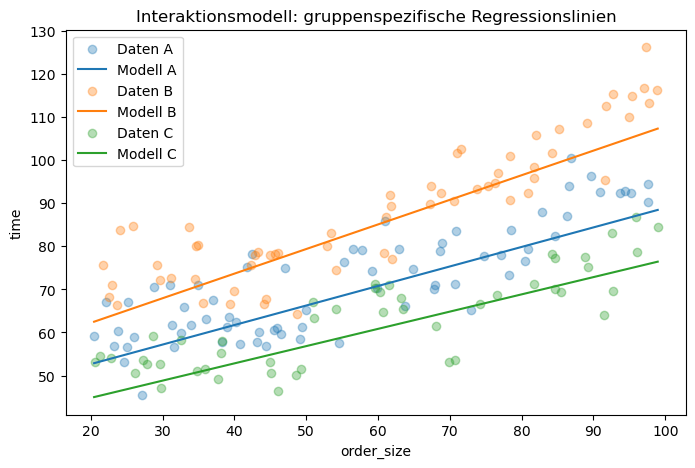

In [18]:
grid = pd.DataFrame({
    "order_size": np.tile(np.linspace(df["order_size"].min(), df["order_size"].max(), 100), 3),
    "temperature": 22,
    "process": np.repeat(["A", "B", "C"], 100),
    "shift": "Frueh"
})

grid["pred"] = m_interaction.predict(grid)

fig, ax = plt.subplots(figsize=(8, 5))

for proc in ["A", "B", "C"]:
    subset_data = df[df["process"] == proc]
    subset_grid = grid[grid["process"] == proc]
    ax.scatter(subset_data["order_size"], subset_data["time"], alpha=0.35, label=f"Daten {proc}")
    ax.plot(subset_grid["order_size"], subset_grid["pred"], label=f"Modell {proc}")

ax.set_xlabel("order_size")
ax.set_ylabel("time")
ax.set_title("Interaktionsmodell: gruppenspezifische Regressionslinien")
ax.legend()
plt.show()

## 13. Additives Modell vs. Interaktionsmodell vergleichen

Da das additive Modell im Interaktionsmodell enthalten ist, können wir einen verschachtelten F-Test verwenden.


In [19]:
sm.stats.anova_lm(m_add, m_interaction)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,173.0,6265.820,0.0,NaN,NaN,NaN
1,171.0,5788.571,2.0,477.249,7.049,0.001


**Interpretation**

Der Test prüft, ob die zusätzlichen Interaktionsterme gemeinsam hilfreich sind.

Nullhypothese:

$$
H_0: \text{alle zusätzlichen Interaktionsterme sind } 0.
$$

Ein kleiner p-Wert spricht dafür, dass die Steigungen zwischen den Gruppen unterschiedlich sind.


## 14. Polynomterm: Nichtlinearität mit linearer Regression abbilden

Jetzt betrachten wir den Zusammenhang zwischen `order_size` und `time` genauer.

Lineares Modell:

$$
Y = \beta_0 + \beta_1 X + \varepsilon
$$

Quadratisches Modell:

$$
Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon
$$

Das quadratische Modell ist weiterhin lineare Regression, weil es linear in den Koeffizienten ist.


In [20]:
m_linear = smf.ols(
    "time ~ order_size + temperature + C(process) + C(shift)",
    data=df
).fit()

m_quad = smf.ols(
    "time ~ order_size + I(order_size**2) + temperature + C(process) + C(shift)",
    data=df
).fit()

print("Lineares Modell")
print("R^2:", round(m_linear.rsquared, 3))
print("Adj. R^2:", round(m_linear.rsquared_adj, 3))

print("\nQuadratisches Modell")
print("R^2:", round(m_quad.rsquared, 3))
print("Adj. R^2:", round(m_quad.rsquared_adj, 3))

Lineares Modell
R^2: 0.875
Adj. R^2: 0.871

Quadratisches Modell
R^2: 0.901
Adj. R^2: 0.897


In [21]:
print(m_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     222.6
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.02e-82
Time:                        23:47:50   Log-Likelihood:                -554.28
No. Observations:                 180   AIC:                             1125.
Df Residuals:                     172   BIC:                             1150.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             41.4721      3

## 15. Lineares vs. quadratisches Modell testen

Auch hier sind die Modelle verschachtelt.  
Das quadratische Modell enthält genau einen zusätzlichen Term: `I(order_size**2)`.


In [22]:
sm.stats.anova_lm(m_linear, m_quad)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,173.0,6265.820,0.0,NaN,NaN,NaN
1,172.0,4982.647,1.0,1283.172,44.295,3.632e-10


## 16. Lineare und quadratische Anpassung visualisieren

Wir halten Temperatur, Prozess und Schicht konstant und zeichnen die vorhergesagten Kurven.


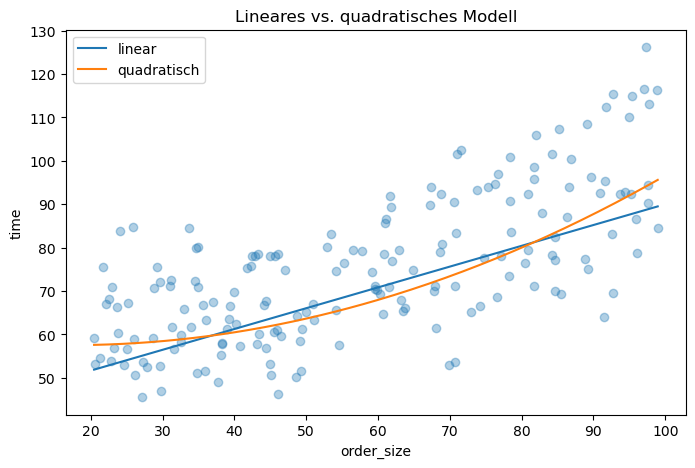

In [23]:
plot_grid = pd.DataFrame({
    "order_size": np.linspace(df["order_size"].min(), df["order_size"].max(), 200),
    "temperature": 22,
    "process": "A",
    "shift": "Frueh"
})

plot_grid["pred_linear"] = m_linear.predict(plot_grid)
plot_grid["pred_quad"] = m_quad.predict(plot_grid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["order_size"], df["time"], alpha=0.35)
ax.plot(plot_grid["order_size"], plot_grid["pred_linear"], label="linear")
ax.plot(plot_grid["order_size"], plot_grid["pred_quad"], label="quadratisch")
ax.set_xlabel("order_size")
ax.set_ylabel("time")
ax.set_title("Lineares vs. quadratisches Modell")
ax.legend()
plt.show()

## 17. Residualplots

Residualplots helfen zu prüfen, ob systematische Muster übrig bleiben.

Ein guter Residualplot zeigt:
- Streuung um 0,
- keine klare Kurve,
- ungefähr konstante Streuung.


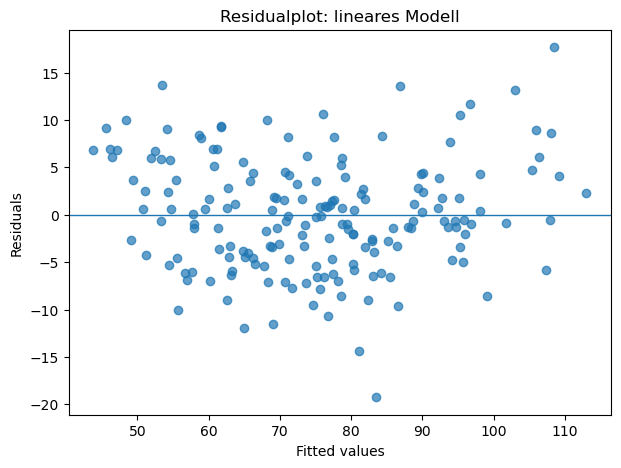

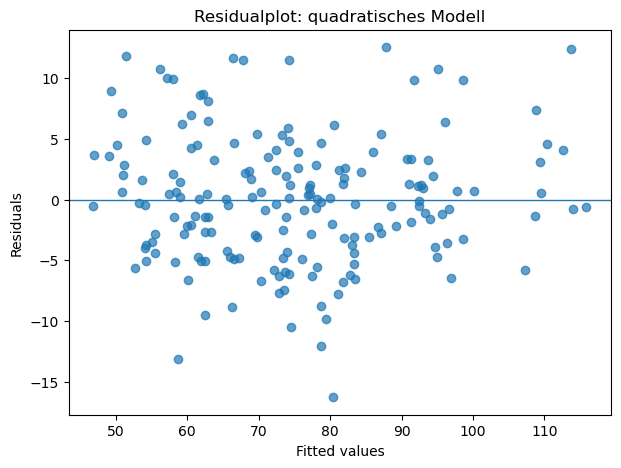

In [24]:
def residual_plot(model, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(model.fittedvalues, model.resid, alpha=0.7)
    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title(title)
    plt.show()

residual_plot(m_linear, "Residualplot: lineares Modell")
residual_plot(m_quad, "Residualplot: quadratisches Modell")

## 18. QQ-Plot der Residuen

Der QQ-Plot prüft grob, ob die Residuen plausibel normalverteilt sind.


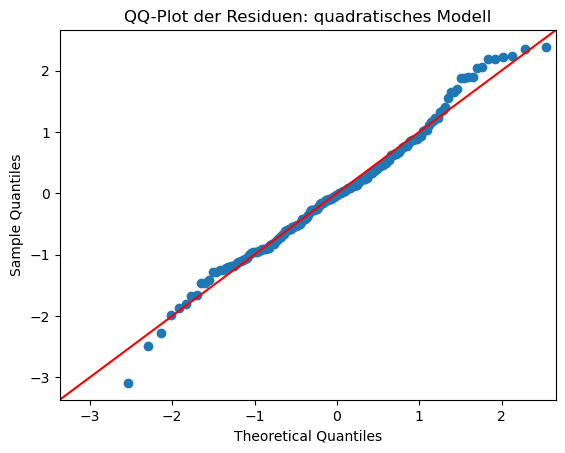

In [31]:
sm.qqplot(m_quad.resid, line="45", fit=True)
plt.title("QQ-Plot der Residuen: quadratisches Modell")
plt.show()

## 19. Mini-Aufgaben im Notebook

Bearbeiten Sie die folgenden Aufgaben direkt in neuen Code-Zellen.

### Aufgabe 1

Schätzen Sie ein Modell mit

$$
\texttt{time} \sim \texttt{temperature} + C(\texttt{shift})
$$

Interpretieren Sie den Koeffizienten für die Nachtschicht.

### Aufgabe 2

Ändern Sie die Referenzkategorie von `shift` auf `Nacht`.  
Welche Koeffizienten ändern sich? Bleiben die Vorhersagen gleich?

### Aufgabe 3

Schätzen Sie ein Modell mit Interaktion zwischen `temperature` und `shift`.

$$
\texttt{time} \sim \texttt{temperature} * C(\texttt{shift})
$$

Gibt es Hinweise darauf, dass die Temperatur in verschiedenen Schichten unterschiedlich wirkt?

### Aufgabe 4

Schätzen Sie ein Modell mit einem kubischen Term von `order_size`:

$$
\texttt{time} \sim \texttt{order\_size} + I(\texttt{order\_size}^2) + I(\texttt{order\_size}^3)
$$

Vergleichen Sie es mit dem quadratischen Modell.  
Ist die zusätzliche Komplexität überzeugend?

### Aufgabe 5

Formulieren Sie am Ende eine kurze Modellentscheidung:
Welches Modell würden Sie für Interpretation verwenden?
Welches Modell würden Sie für Vorhersage prüfen?
Welche zusätzliche Validierung wäre sinnvoll?


In [26]:
# Platz für Aufgabe 1


In [27]:
# Platz für Aufgabe 2


In [28]:
# Platz für Aufgabe 3


In [29]:
# Platz für Aufgabe 4


In [30]:
# Platz für Aufgabe 5


## 20. Kurze Takeaways

- `C(variable)` nimmt qualitative Prädiktoren korrekt ins Modell auf.
- Die Referenzkategorie bestimmt die Bedeutung der Dummy-Koeffizienten.
- Referenzwechsel ändern Koeffizienten, aber nicht die Modellvorhersagen.
- Interaktionen erlauben unterschiedliche Steigungen oder Effekte je Gruppe.
- Polynomterme erlauben Krümmung, bleiben aber lineare Regression in den Koeffizienten.
- Höheres `R^2` allein reicht nicht: Residualplots, F-Tests, Interpretierbarkeit und fachliche Plausibilität sind entscheidend.
